In [3]:
import yfinance as yf
import pandas as pd

data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759071,24.816605,24.053186,24.170466,237458000


In [5]:
data.columns = data.columns.get_level_values(0)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759071,24.816605,24.053186,24.170466,237458000


In [6]:
print(data.shape)
print(data.info())
print(data.index.min(), "to", data.index.max())
print(data.isnull().sum())

(2516, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2516 non-null   float64
 1   High    2516 non-null   float64
 2   Low     2516 non-null   float64
 3   Open    2516 non-null   float64
 4   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB
None
2015-01-02 00:00:00 to 2024-12-31 00:00:00
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


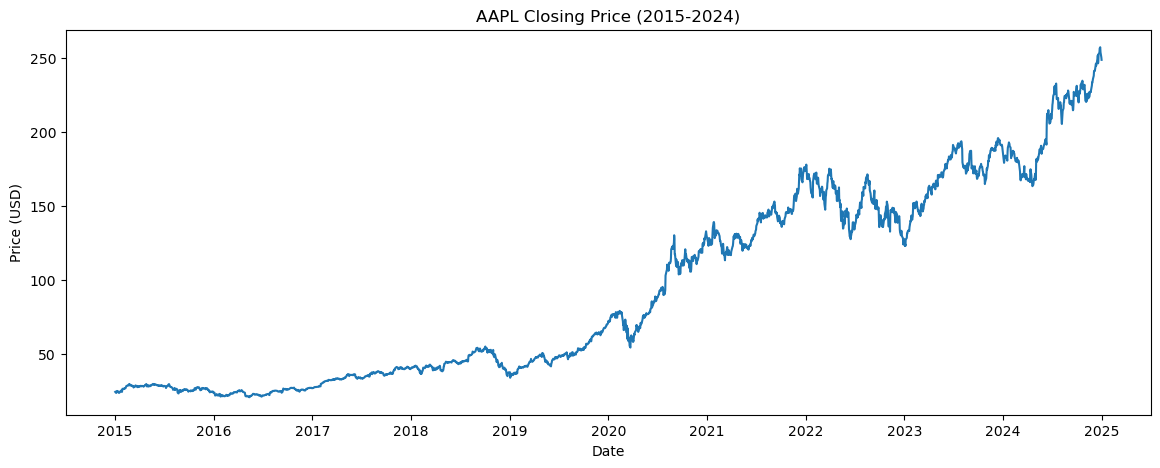

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(data.index, data['Close'])
plt.title('AAPL Closing Price (2015-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

<AxesSubplot:title={'center':'AAPL Monthly Average Closing Price'}, xlabel='Date'>

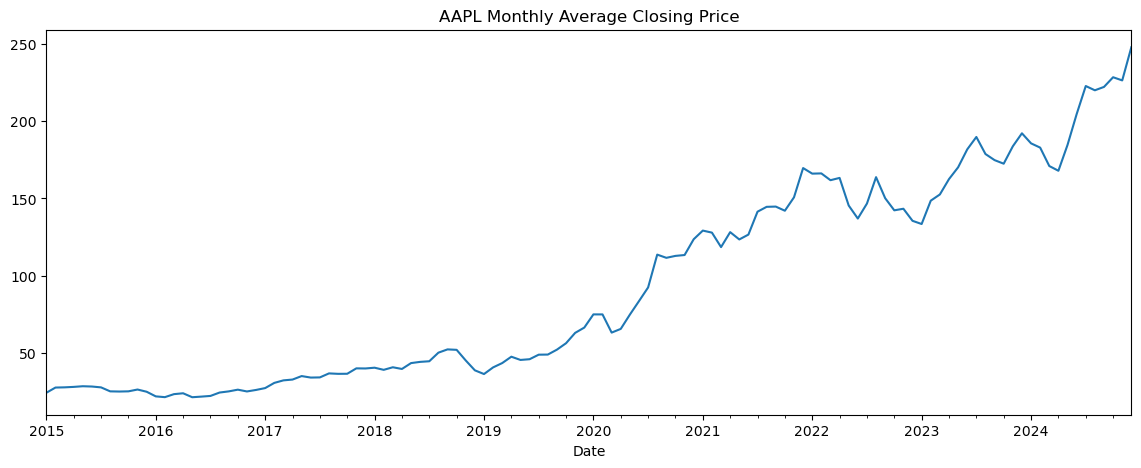

In [13]:
monthly = data['Close'].resample('M').mean()
monthly.plot(figsize=(14,5), title='AAPL Monthly Average Closing Price')

In [14]:
print(monthly.shape)
monthly.head(12)

(120,)


Date
2015-01-31    24.482813
2015-02-28    27.848825
2015-03-31    27.984926
2015-04-30    28.278282
2015-05-31    28.700759
2015-06-30    28.511379
2015-07-31    27.960062
2015-08-31    25.394056
2015-09-30    25.276997
2015-10-31    25.403022
2015-11-30    26.575025
2015-12-31    25.144212
Freq: M, Name: Close, dtype: float64

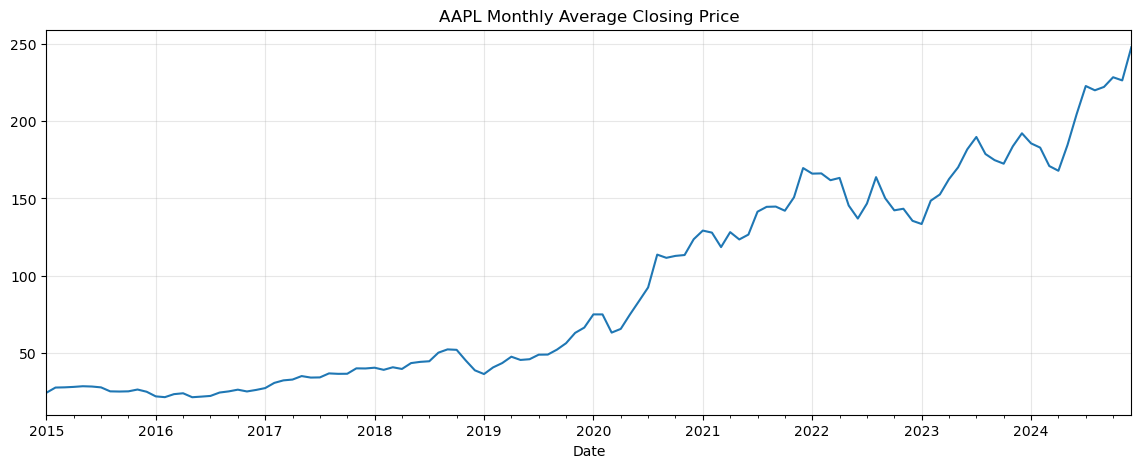

In [15]:
monthly.plot(figsize=(14,5), title='AAPL Monthly Average Closing Price')
plt.grid(True, alpha=0.3)
plt.show()

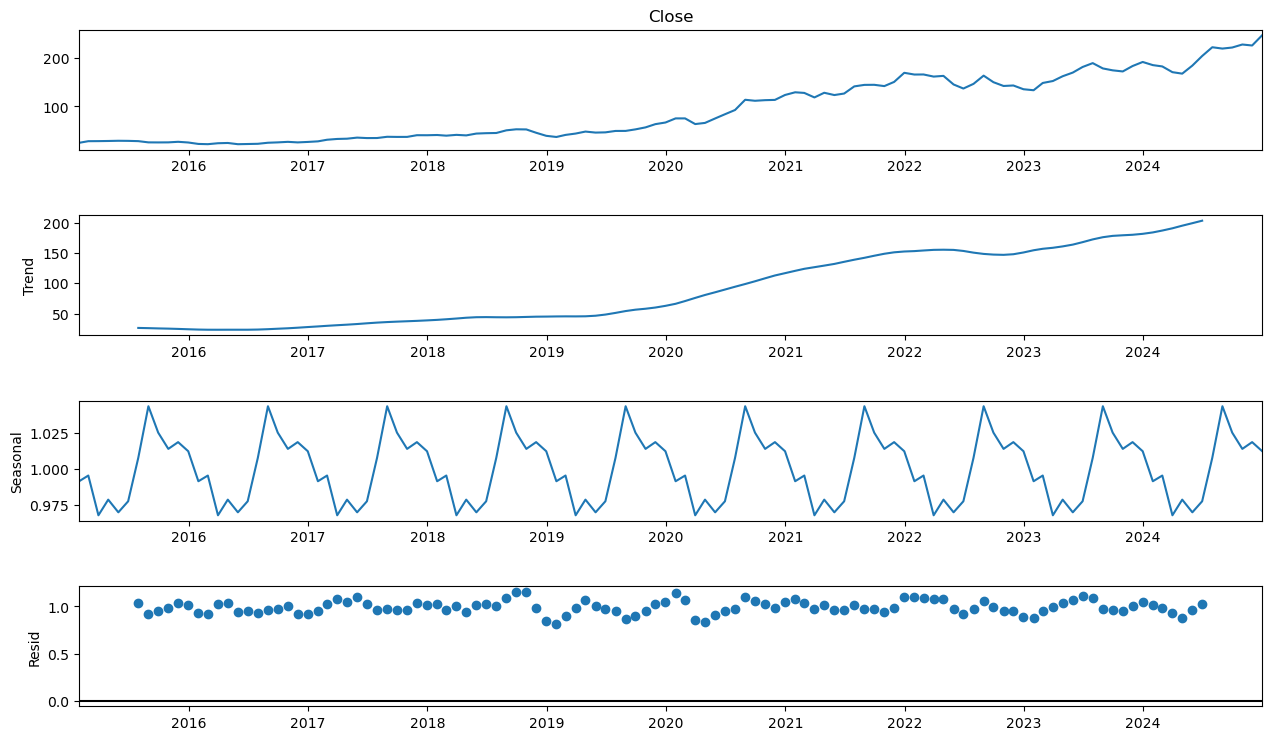

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly, model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(14,8)
plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 1.4960720357528652
p-value: 0.9975097216734836


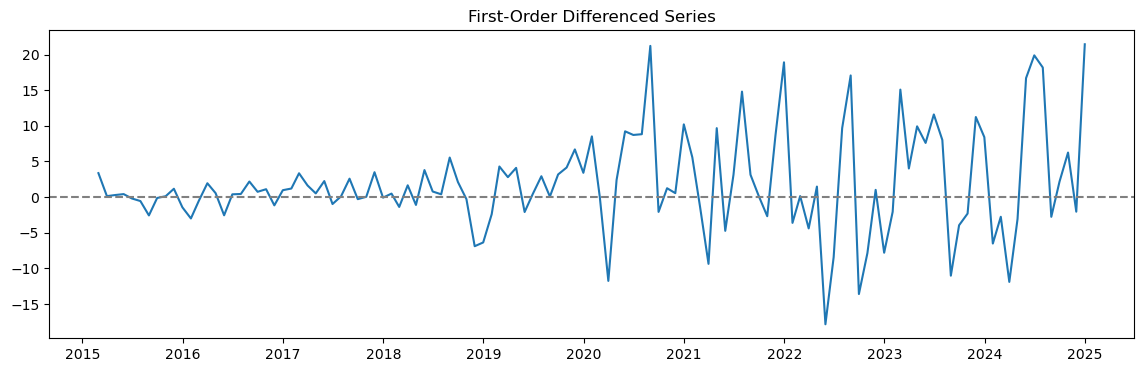

In [22]:
diff = monthly.diff().dropna()

plt.figure(figsize=(14,4))
plt.plot(diff.index, diff)
plt.title('First-Order Differenced Series')
plt.axhline(0, color='gray', linestyle='--')
plt.show()

In [23]:
result_diff = adfuller(diff)
print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic: -3.351545556767259
p-value: 0.012725844622400215


/Users/darkos/opt/anaconda3/lib/python3.9/site-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


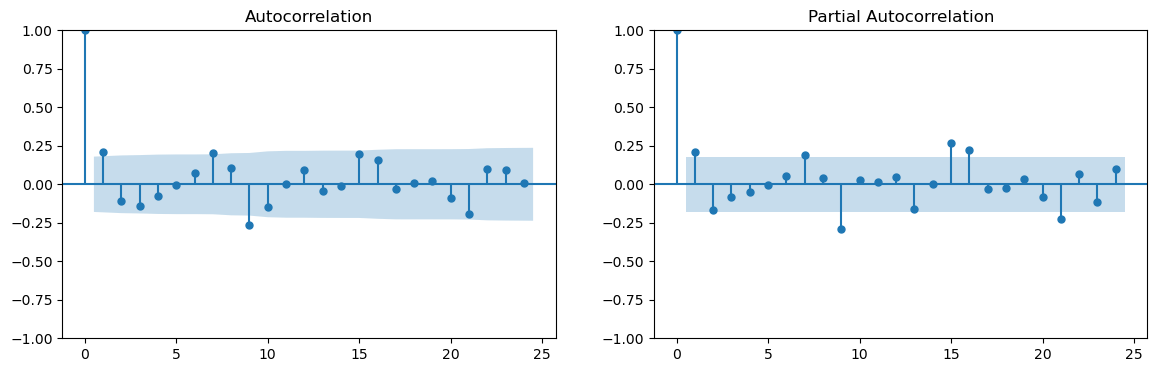

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff, ax=axes[0], lags=24)
plot_pacf(diff, ax=axes[1], lags=24)
plt.show()

In [30]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -397.843
Date:                Tue, 07 Jul 2026   AIC                            801.685
Time:                        21:48:31   BIC                            810.023
Sample:                    01-31-2015   HQIC                           805.071
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0328      0.233     -0.141      0.888      -0.490       0.424
ma.L1          0.3480      0.239      1.455      0.146      -0.121       0.817
sigma2        46.8815      4.633     10.118      0.0

In [32]:
for order in [(0,1,0), (1,1,0), (0,1,1), (2,1,2)]:
    m = ARIMA(monthly, order=order).fit()
    print(order, 'AIC:', round(m.aic, 2))
    

(0, 1, 0) AIC: 808.02
(1, 1, 0) AIC: 801.26
(0, 1, 1) AIC: 799.7
(2, 1, 2) AIC: 805.27


In [35]:
final_model = ARIMA(monthly, order=(0,1,1)).fit()

forecast = final_model.forecast(steps=12)
print(forecast)

2025-01-31    254.946385
2025-02-28    254.946385
2025-03-31    254.946385
2025-04-30    254.946385
2025-05-31    254.946385
2025-06-30    254.946385
2025-07-31    254.946385
2025-08-31    254.946385
2025-09-30    254.946385
2025-10-31    254.946385
2025-11-30    254.946385
2025-12-31    254.946385
Freq: M, Name: predicted_mean, dtype: float64


In [37]:
train = monthly[:-12]
test = monthly[-12:]

eval_model = ARIMA(train, order=(0,1,1)).fit()
eval_forecast = eval_model.forecast(steps=12)

print(eval_forecast)
print(test)

2024-01-31    193.554201
2024-02-29    193.554201
2024-03-31    193.554201
2024-04-30    193.554201
2024-05-31    193.554201
2024-06-30    193.554201
2024-07-31    193.554201
2024-08-31    193.554201
2024-09-30    193.554201
2024-10-31    193.554201
2024-11-30    193.554201
2024-12-31    193.554201
Freq: M, Name: predicted_mean, dtype: float64
Date
2024-01-31    185.623143
2024-02-29    182.869384
2024-03-31    170.981464
2024-04-30    167.920212
2024-05-31    184.609338
2024-06-30    204.491758
2024-07-31    222.669773
2024-08-31    219.911152
2024-09-30    222.093127
2024-10-31    228.344352
2024-11-30    226.303167
2024-12-31    247.740029
Freq: M, Name: Close, dtype: float64


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np 

mae = mean_absolute_error(test, eval_forecast)
rmse = np.sqrt(mean_squared_error(test, eval_forecast))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 24.37011782324829
RMSE: 27.566837740559375


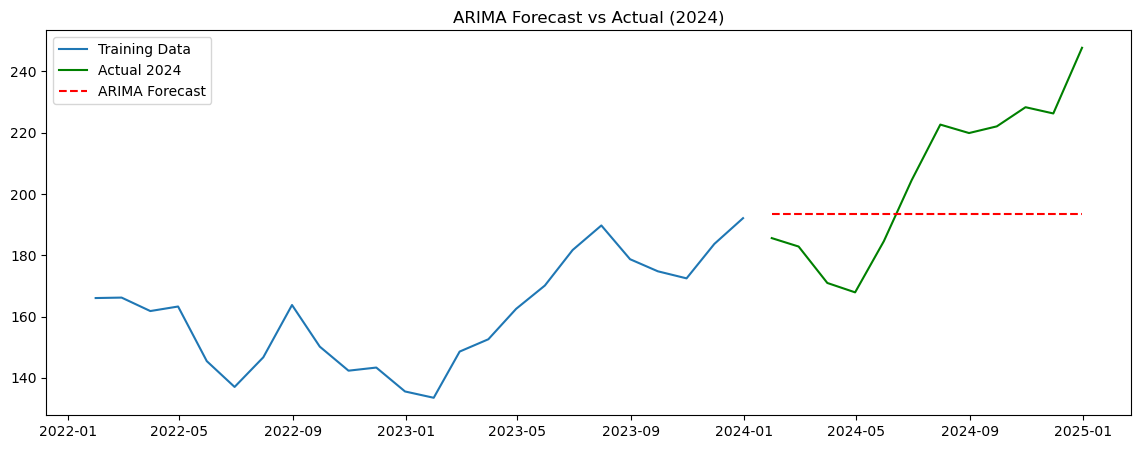

In [40]:
plt.figure(figsize=(14,5))
plt.plot(train.index[-24:], train[-24:], label='Training Data')
plt.plot(test.index, test, label='Actual 2024', color='green')
plt.plot(test.index, eval_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.legend()
plt.title('ARIMA Forecast vs Actual (2024)')
plt.show()

In [41]:
prophet_df = monthly.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2015-01-31,24.482813
1,2015-02-28,27.848825
2,2015-03-31,27.984926
3,2015-04-30,28.278282
4,2015-05-31,28.700759


In [43]:
from prophet import Prophet
prophet_model = Prophet()
prophet_model.fit(prophet_df)

12:28:51 - cmdstanpy - INFO - Chain [1] start processing
12:28:53 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
future = prophet_model.make_future_dataframe(periods=12, freq='M')
forcast = prophet_model.predict(future)

forcast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
120,2025-01-31,223.233671,207.603999,239.358387
121,2025-02-28,222.381959,207.284637,237.525799
122,2025-03-31,220.393405,203.978800,236.795838
123,2025-04-30,223.528023,207.797701,238.908322
124,2025-05-31,226.198919,210.658349,241.112030
125,2025-06-30,230.579858,215.300044,245.185724
126,2025-07-31,237.296377,221.235776,252.015989
127,2025-08-31,241.578345,225.842453,256.950116
128,2025-09-30,240.313849,224.708641,256.134870
129,2025-10-31,240.821375,225.965747,256.389315


In [48]:
train_p = prophet_df[:-12]
test_p = prophet_df[-12:]

eval_prophet = Prophet()
eval_prophet.fit(train_p)

future_eval = eval_prophet.make_future_dataframe(periods=12, freq='M')
forecast_eval = eval_prophet.predict(future_eval)

prophet_pred = forecast_eval['yhat'][-12:].values

13:20:41 - cmdstanpy - INFO - Chain [1] start processing
13:20:41 - cmdstanpy - INFO - Chain [1] done processing


In [49]:
mae_p = mean_absolute_error(test_p['y'], prophet_pred)
rmse_p = np.sqrt(mean_squared_error(test_p['y'], prophet_pred))

print('Prophet MAE:', mae_p)
print('Prophet RMSE:', rmse_p)

Prophet MAE: 15.761353036831613
Prophet RMSE: 17.854938099443146


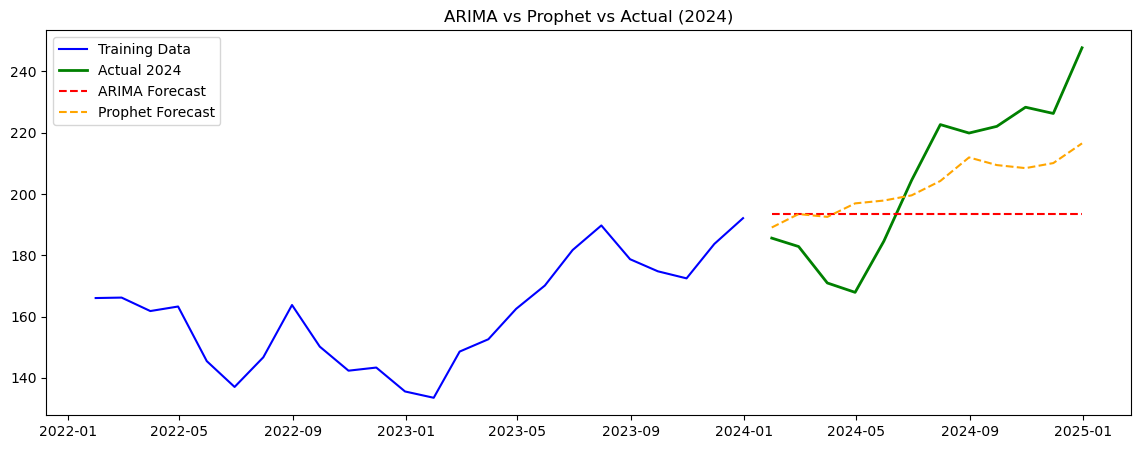

In [50]:
plt.figure(figsize=(14,5))
plt.plot(train.index[-24:], train[-24:], label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual 2024', color='green', linewidth=2)
plt.plot(test.index, eval_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(test_p['ds'], prophet_pred, label='Prophet Forecast', color='orange', linestyle='--')
plt.legend()
plt.title('ARIMA vs Prophet vs Actual (2024)')
plt.show()

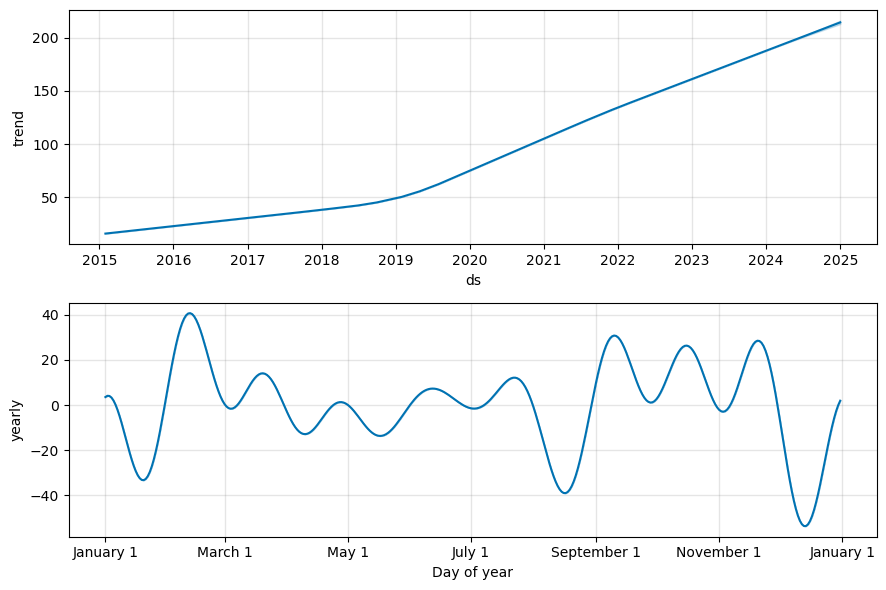

In [51]:
fig2 = eval_prophet.plot_components(forecast_eval)
plt.show()